2026-02-07 16:37:50.018175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770482270.277994      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770482270.350045      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770482270.973577      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770482270.973642      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770482270.973645      17 computation_placer.cc:177] computation placer alr

Preparing countries with per-country scaling..
Australia : 710 sequences (Train:496, Val:107, Test:107)
Brazil : 710 sequences (Train:496, Val:107, Test:107)
Canada : 710 sequences (Train:496, Val:107, Test:107)
China : 710 sequences (Train:496, Val:107, Test:107)
France : 710 sequences (Train:496, Val:107, Test:107)
Germany : 710 sequences (Train:496, Val:107, Test:107)
India : 710 sequences (Train:496, Val:107, Test:107)
Indonesia : 710 sequences (Train:496, Val:107, Test:107)
Italy : 710 sequences (Train:496, Val:107, Test:107)
Japan : 710 sequences (Train:496, Val:107, Test:107)
Mexico : 710 sequences (Train:496, Val:107, Test:107)
Netherlands : 710 sequences (Train:496, Val:107, Test:107)
Norway : 710 sequences (Train:496, Val:107, Test:107)
Poland : 710 sequences (Train:496, Val:107, Test:107)
South Africa : 710 sequences (Train:496, Val:107, Test:107)
Spain : 710 sequences (Train:496, Val:107, Test:107)
Sweden : 710 sequences (Train:496, Val:107, Test:107)
Turkey : 710 sequences

2026-02-07 16:38:06.063823: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.2715 - mae: 0.4366 - val_loss: 0.0676 - val_mae: 0.2195 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0879 - mae: 0.2520 - val_loss: 0.0678 - val_mae: 0.2197 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0802 - mae: 0.2366 - val_loss: 0.0717 - val_mae: 0.2232 - learning_rate: 0.0010
Epoch 4/100
11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0822 - mae: 0.2400 
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0800 - mae: 0.2372 - val_loss: 0.0677 - val_mae: 0.2195 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0732 - mae: 0.2287 - val_loss: 0.0678 - val_mae: 0.2195 - learning_rate: 5.0000e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0778 - mae: 0.2326 - val_loss: 0.0684 - val_mae: 0.2197 - learning_rate: 5.0000e-04
Epoch 6: e

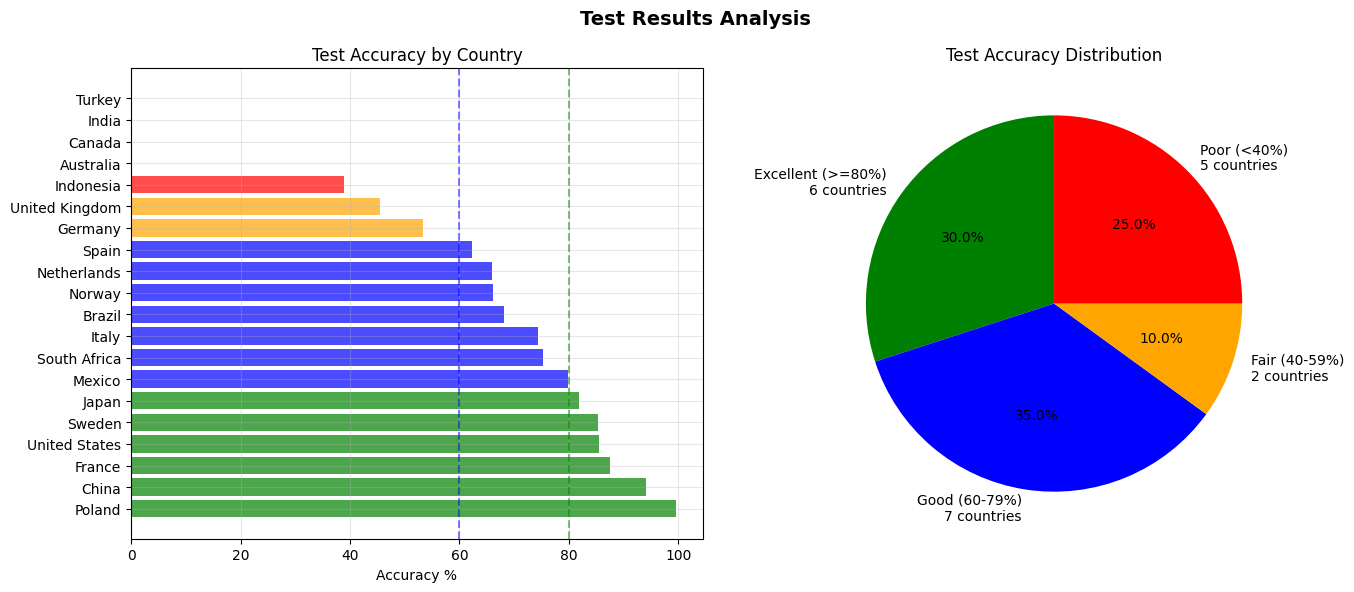


Test analysis charts saved and displayed

MODEL TRAINING COMPLETE
Trained 20 separate LSTM models
Average train accuracy: 79.1%
Average test accuracy: 58.2%
Average validation accuracy: 57.0%


In [1]:
# CO2 LSTM FORECASTER - PER COUNTRY (TRAIN-VALIDATE-TEST)

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. LOAD DATA
file_path = "/kaggle/input/climate-and-energy-consumption-dataset-20202024/global_climate_energy_2020_2024.csv"
df = pd.read_csv(file_path)

# Convert date
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date'])

# Clean country names
df['country'] = df['country'].astype(str).str.strip().str.title()
df = df.sort_values(['country', 'date'])

# 2. SIMPLE FEATURES
FEATURES = [
    'co2_emission',
    'industrial_activity_index', 
    'energy_consumption',
    'avg_temperature',
    'energy_price'
]

#Target: predict CO2 for next day
df['co2_next_day'] = df.groupby('country')['co2_emission'].shift(-1)

#Remove last row per country
df = df[df.groupby('country')['co2_emission'].transform('count') - df.groupby('country').cumcount() > 1]

#Convert to numeric and drop NaN
for col in FEATURES + ['co2_next_day']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=FEATURES + ['co2_next_day'])

# 3CREATE SEQUENCES FOR EACH COUNTRY
WINDOW = 9

def create_sequences(df_country, window):
    if len(df_country) < window + 20:
        return None, None, None, None
        #Scale features for this country only
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_data = scaler_x.fit_transform(df_country[FEATURES])
    y_data = scaler_y.fit_transform(df_country[['co2_next_day']])
    
    X, y = [], []
    for i in range(len(X_data) - window):
        X.append(X_data[i:i + window])
        y.append(y_data[i + window])
    return np.array(X), np.array(y), scaler_x, scaler_y

#4.PROCESS EACH COUNTRY SEPARATELY

country_models = {}
country_histories = {}
country_names = []

print("Preparing countries with per-country scaling..")
for country in sorted(df['country'].unique()):
    df_c = df[df['country'] == country].copy()
    
    X, y, scaler_x, scaler_y = create_sequences(df_c, WINDOW)
    
    if X is None or len(X) < 100:
        print(f"{country} : insufficient data, skipping")
        continue
    
    # 70% train, 15% validation, 15% test
    n = len(X)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    
    X_train = X[:train_end]
    X_val = X[train_end:val_end]
    X_test = X[val_end:]
    y_train = y[:train_end]
    y_val = y[train_end:val_end]
    y_test = y[val_end:]
    
    country_models[country] = {
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'scaler_x': scaler_x,
        'scaler_y': scaler_y,
        'df': df_c
    }
    
    country_names.append(country)
    
    print(f"{country} : {len(X)} sequences (Train:{len(X_train)}, Val:{len(X_val)}, Test:{len(X_test)})")

print(f"\nTotal countries: {len(country_names)}")

# 5. BUILD SIMPLE LSTM MODEL

def build_lstm():
    model = Sequential([
        Input(shape=(WINDOW, len(FEATURES))),
        LSTM(32),
        Dropout(0.2),
        Dense(1)  
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model
    
# 6. TRAIN MODEL FOR EACH COUNTRY SEPARATELY

print("\nTraining models for each country...\n")

for country in country_names:
    data = country_models[country]
    
    print(f"--- Training {country} ---")
    
    model = build_lstm()
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    lr_reduce = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
    
    # Train with validation set for early stopping
    history = model.fit(
        data['X_train'], data['y_train'],
        epochs=100,
        batch_size=32,
        validation_data=(data['X_val'], data['y_val']),
        callbacks=[early_stop, lr_reduce],
        verbose=1
    )
    
    country_models[country]['model'] = model
    country_histories[country] = history
    
    print(f"Finished {country}: {len(history.history['loss'])} epochs\n")

# 7. TRAINING SUMMARY

print(f"\n{'='*60}")
print("TRAINING RESULTS")
print(f"{'='*60}")

train_accuracies = []

for country in country_names:
    history = country_histories[country]
    epochs = len(history.history['loss'])
    final_train_mae = history.history['mae'][-1]
    final_val_mae = history.history['val_mae'][-1]
    
    train_accuracy = max(0, (1 - final_train_mae) * 100)
    train_accuracies.append(train_accuracy)
    
    print(f"{country:<20} Epochs: {epochs:>3}  Train MAE: {final_train_mae:.4f}  Val MAE: {final_val_mae:.4f}")

avg_train_accuracy = np.mean(train_accuracies)

print(f"\nAverage Train Accuracy: {avg_train_accuracy:.1f}%")
print(f"{'='*60}")

# 8. TEST - DETAILED REPRESENTATION FROM TEST SET
print(f"\n{'='*60}")
print("TEST RESULTS - DETAILED WINDOWS")
print(f"{'='*60}")

test_results = []

for country in country_names:
    data = country_models[country]
    model = data['model']
    scaler_x = data['scaler_x']
    scaler_y = data['scaler_y']
    df_c = data['df'].reset_index(drop=True)
    
    test_size = len(data['X_test'])
    if test_size == 0:
        continue
    
    test_idx = random.randint(0, test_size - 1)
    train_end = len(data['X_train'])
    val_end = train_end + len(data['X_val'])
    seq_start_idx = val_end + test_idx
    
    window_df = df_c.iloc[seq_start_idx:seq_start_idx + WINDOW]
    actual_co2 = df_c.iloc[seq_start_idx + WINDOW]['co2_emission']
    
    print(f"\n--- {country} ---")
    print(f"Window dates: {window_df['date'].iloc[0].strftime('%Y-%m-%d')} to {window_df['date'].iloc[-1].strftime('%Y-%m-%d')}")
    print("Day | Date       | CO2    | Industrial | Energy | Temp  | Price")
    print("-" * 75)
    
    for i, (idx, row) in enumerate(window_df.iterrows()):
        print(f"{i+1:>3} | {row['date'].strftime('%Y-%m-%d')} | {row['co2_emission']:>6.1f} | "
              f"{row['industrial_activity_index']:>10.2f} | {row['energy_consumption']:>6.1f} | "
              f"{row['avg_temperature']:>5.1f} | {row['energy_price']:>5.1f}")
    
    features = window_df[FEATURES].values
    features_scaled = scaler_x.transform(features)
    X_input = features_scaled.reshape(1, WINDOW, len(FEATURES))
    
    pred_scaled = model.predict(X_input, verbose=0)
    pred_co2 = scaler_y.inverse_transform(pred_scaled)[0, 0]
    
    error = abs(pred_co2 - actual_co2)
    error_pct = (error / actual_co2) * 100 if actual_co2 != 0 else 0
    accuracy = max(0, 100 - error_pct)
    
    test_results.append({
        'country': country,
        'predicted': pred_co2,
        'actual': actual_co2,
        'error_pct': error_pct,
        'accuracy': accuracy
    })
    
    print(f"Predicted day 10 CO2: {pred_co2:.2f}")
    print(f"Actual day 10 CO2:    {actual_co2:.2f}")
    print(f"Error: {error:.2f} ({error_pct:.1f}%)")
    print(f"Accuracy: {accuracy:.1f}%")

# 9. TEST SUMMARY TABLE

print(f"\n{'='*60}")
print("TEST SUMMARY")
print(f"{'='*60}")

test_results.sort(key=lambda x: x['accuracy'], reverse=True)

print(f"{'Country':<20} {'Predicted':>10} {'Actual':>10} {'Error%':>8} {'Accuracy':>10}")
print("-" * 60)

for res in test_results:
    print(f"{res['country']:<20} {res['predicted']:>10.1f} {res['actual']:>10.1f} "
          f"{res['error_pct']:>8.1f} {res['accuracy']:>9.1f}%")

avg_test_accuracy = np.mean([r['accuracy'] for r in test_results])
print(f"\nAverage Test Accuracy: {avg_test_accuracy:.1f}%")
print(f"{'='*60}")

# 10 VALIDATION - DETAILED REPRESENTATION FROM VALIDATION SET 

print(f"\n{'='*60}")
print("VALIDATION RESULTS - DETAILED WINDOWS")
print(f"{'='*60}")

validation_results = []

for country in country_names:
    data = country_models[country]
    model = data['model']
    scaler_x = data['scaler_x']
    scaler_y = data['scaler_y']
    df_c = data['df'].reset_index(drop=True)
    
    val_size = len(data['X_val'])
    if val_size == 0:
        continue
    
    val_idx = random.randint(0, val_size - 1)
    train_end = len(data['X_train'])
    seq_start_idx = train_end + val_idx
    
    window_df = df_c.iloc[seq_start_idx:seq_start_idx + WINDOW]
    actual_co2 = df_c.iloc[seq_start_idx + WINDOW]['co2_emission']
    
    print(f"\n--- {country} ---")
    print(f"Window dates: {window_df['date'].iloc[0].strftime('%Y-%m-%d')} to {window_df['date'].iloc[-1].strftime('%Y-%m-%d')}")
    print("Day | Date       | CO2    | Industrial | Energy | Temp  | Price")
    print("-" * 75)
    
    for i, (idx, row) in enumerate(window_df.iterrows()):
        print(f"{i+1:>3} | {row['date'].strftime('%Y-%m-%d')} | {row['co2_emission']:>6.1f} | "
              f"{row['industrial_activity_index']:>10.2f} | {row['energy_consumption']:>6.1f} | "
              f"{row['avg_temperature']:>5.1f} | {row['energy_price']:>5.1f}")
    
    features = window_df[FEATURES].values
    features_scaled = scaler_x.transform(features)
    X_input = features_scaled.reshape(1, WINDOW, len(FEATURES))
    
    pred_scaled = model.predict(X_input, verbose=0)
    pred_co2 = scaler_y.inverse_transform(pred_scaled)[0, 0]
    
    error = abs(pred_co2 - actual_co2)
    error_pct = (error / actual_co2) * 100 if actual_co2 != 0 else 0
    accuracy = max(0, 100 - error_pct)
    
    validation_results.append({
        'country': country,
        'predicted': pred_co2,
        'actual': actual_co2,
        'error_pct': error_pct,
        'accuracy': accuracy
    })
    
    print(f"Predicted day 10 CO2: {pred_co2:.2f}")
    print(f"Actual day 10 CO2:    {actual_co2:.2f}")
    print(f"Error: {error:.2f} ({error_pct:.1f}%)")
    print(f"Accuracy: {accuracy:.1f}%")

# 11. VALIDATION SUMMARY TABLE

print(f"\n{'='*60}")
print("VALIDATION SUMMARY")
print(f"{'='*60}")

validation_results.sort(key=lambda x: x['accuracy'], reverse=True)

print(f"{'Country':<20} {'Predicted':>10} {'Actual':>10} {'Error%':>8} {'Accuracy':>10}")
print("-" * 60)

for res in validation_results:
    print(f"{res['country']:<20} {res['predicted']:>10.1f} {res['actual']:>10.1f} "
          f"{res['error_pct']:>8.1f} {res['accuracy']:>9.1f}%")

avg_val_accuracy = np.mean([r['accuracy'] for r in validation_results])
print(f"\nAverage Validation Accuracy: {avg_val_accuracy:.1f}%")
print(f"{'='*60}")


# 12. FINAL COMPARISON TABLE

print(f"\n{'='*60}")
print("FINAL COMPARISON: TRAIN / TEST / VALIDATION")
print(f"{'='*60}")
print(f"{'Country':<20} {'Train MAE':>10} {'Test Acc':>10} {'Val Acc':>10}")
print("-" * 60)

for country in country_names:
    train_mae = country_histories[country].history['mae'][-1]
    test_acc = next((r['accuracy'] for r in test_results if r['country'] == country), 0)
    val_acc = next((r['accuracy'] for r in validation_results if r['country'] == country), 0)
    print(f"{country:<20} {train_mae:>10.4f} {test_acc:>9.1f}% {val_acc:>9.1f}%")

print(f"\n{'Averages':<20} {'':>10} {avg_test_accuracy:>9.1f}% {avg_val_accuracy:>9.1f}%")
print(f"{'='*60}")

# 13. VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Test Results Analysis', fontsize=14, fontweight='bold')

countries = [r['country'] for r in test_results]
accs = [r['accuracy'] for r in test_results]

ax1 = axes[0]
colors = ['green' if a >= 80 else 'blue' if a >= 60 else 'orange' if a >= 40 else 'red' for a in accs]
ax1.barh(countries, accs, color=colors, alpha=0.7)
ax1.set_xlabel('Accuracy %')
ax1.set_title('Test Accuracy by Country')
ax1.axvline(80, color='green', linestyle='--', alpha=0.5)
ax1.axvline(60, color='blue', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
excellent = sum(1 for a in accs if a >= 80)
good = sum(1 for a in accs if 60 <= a < 80)
fair = sum(1 for a in accs if 40 <= a < 60)
poor = sum(1 for a in accs if a < 40)

labels = []
sizes = []
colors_pie = []

if excellent > 0:
    labels.append(f'Excellent (>=80%)\n{excellent} countries')
    sizes.append(excellent)
    colors_pie.append('green')
if good > 0:
    labels.append(f'Good (60-79%)\n{good} countries')
    sizes.append(good)
    colors_pie.append('blue')
if fair > 0:
    labels.append(f'Fair (40-59%)\n{fair} countries')
    sizes.append(fair)
    colors_pie.append('orange')
if poor > 0:
    labels.append(f'Poor (<40%)\n{poor} countries')
    sizes.append(poor)
    colors_pie.append('red')

if sizes:
    ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Test Accuracy Distribution')

plt.tight_layout()
plt.savefig('/tmp/test_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTest analysis charts saved and displayed")

# 14. PREDICTION FUNCTION

def predict_co2_simple(country, co2_9days, industrial_9days, energy_9days, temp_9days, price_9days):
    if country not in country_models:
        raise ValueError(f"Country {country} not found in trained models")
    
    data = country_models[country]
    model = data['model']
    scaler_x = data['scaler_x']
    scaler_y = data['scaler_y']
    
    features = np.column_stack([co2_9days, industrial_9days, energy_9days, temp_9days, price_9days])
    features_scaled = scaler_x.transform(features)
    X_input = features_scaled.reshape(1, WINDOW, len(FEATURES))
    
    pred_scaled = model.predict(X_input, verbose=0)
    pred_real = scaler_y.inverse_transform(pred_scaled)[0, 0]
    
    return pred_real

# FINAL

print(f"\n{'='*60}")
print("MODEL TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Trained {len(country_names)} separate LSTM models")
print(f"Average train accuracy: {avg_train_accuracy:.1f}%")
print(f"Average test accuracy: {avg_test_accuracy:.1f}%")
print(f"Average validation accuracy: {avg_val_accuracy:.1f}%")
print(f"{'='*60}")